<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47070 entries, 0 to 47069
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        47070 non-null  object 
 1   adm2_id     47070 non-null  int64  
 2   ADM2_PCODE  47070 non-null  object 
 3   n_pixels    47070 non-null  int64  
 4   rfh         47070 non-null  float64
 5   rfh_avg     47070 non-null  float64
 6   r1h         47010 non-null  float64
 7   r1h_avg     47010 non-null  float64
 8   r3h         46830 non-null  float64
 9   r3h_avg     46830 non-null  float64
 10  rfq         47070 non-null  float64
 11  r1q         47010 non-null  float64
 12  r3q         46830 non-null  float64
 13  version     47070 non-null  object 
dtypes: float64(9), int64(2), object(3)
memory usage: 5.0+ MB
[1009006 1009007 1009008 1009009 1009010 1009011 1009012 1009013 1009014
 1009015 1009016 1009017 1009018 1009019 1009020 1009021 1009022 1009023
 1009024 1009025 1009026 10

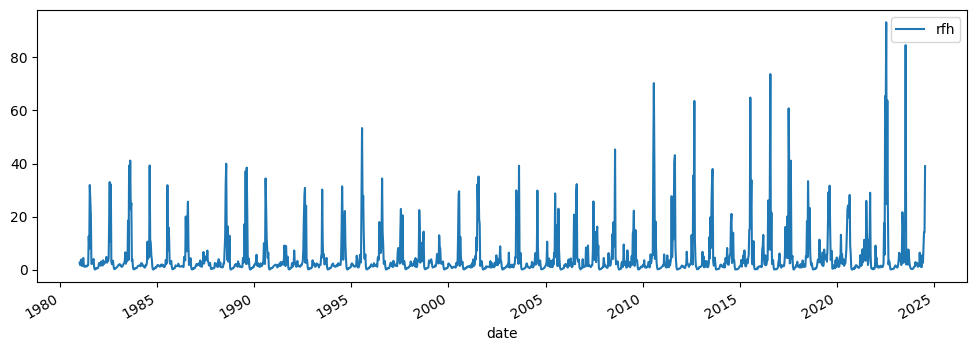

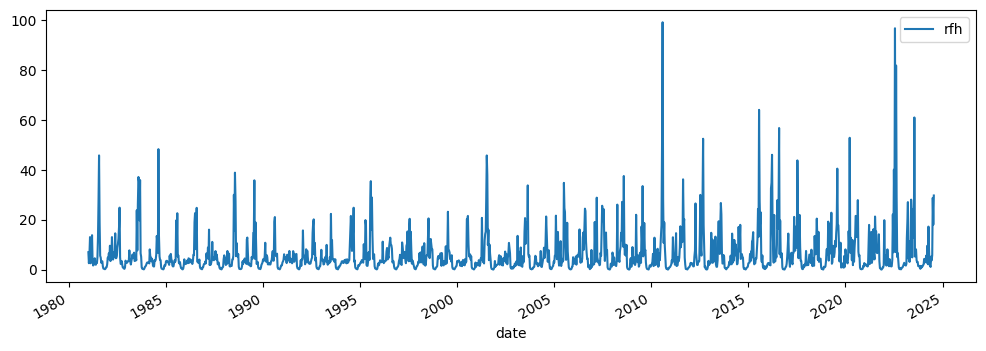

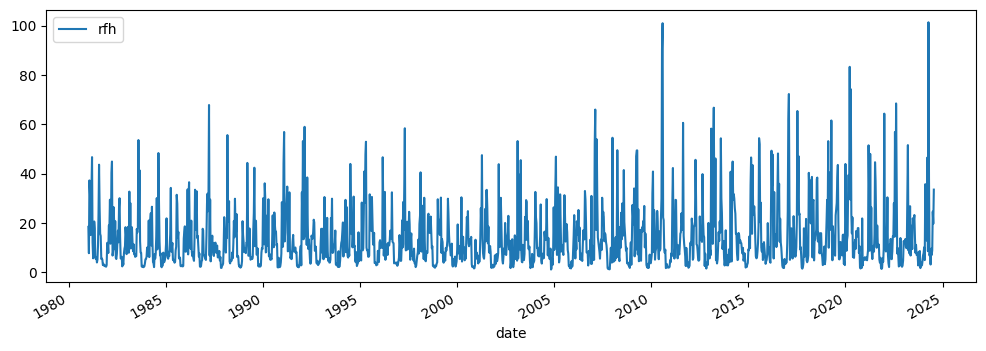

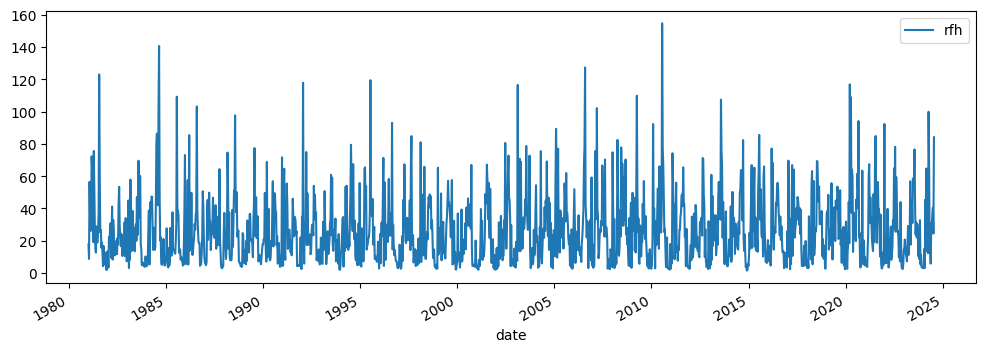

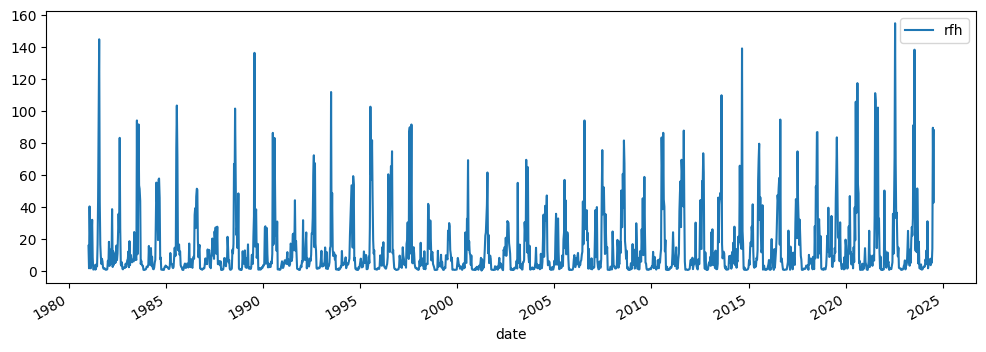

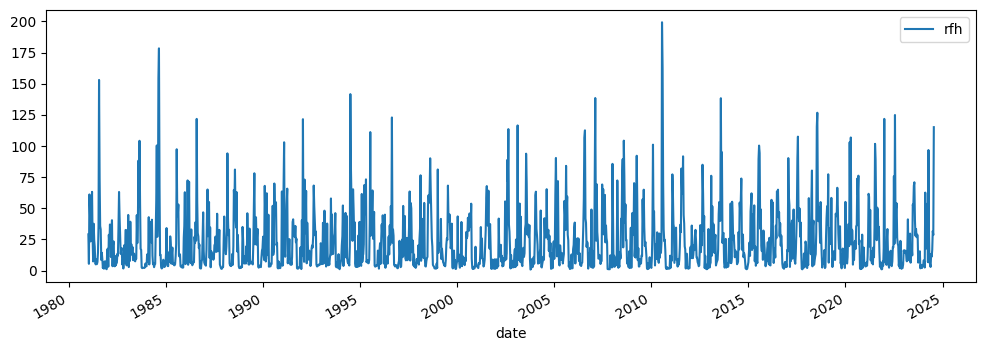

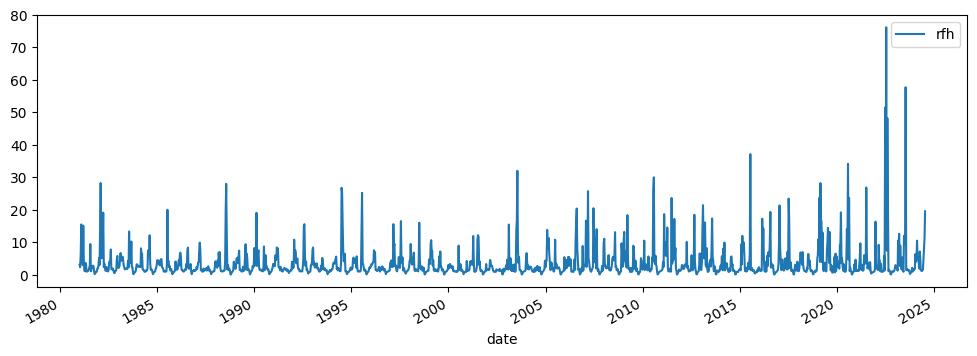

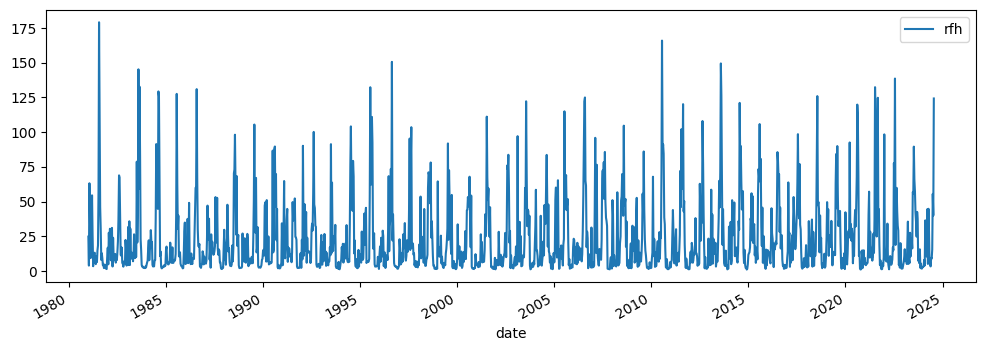

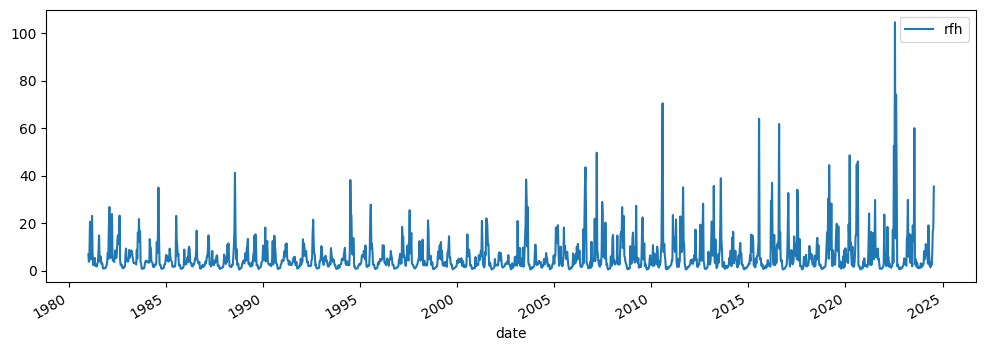

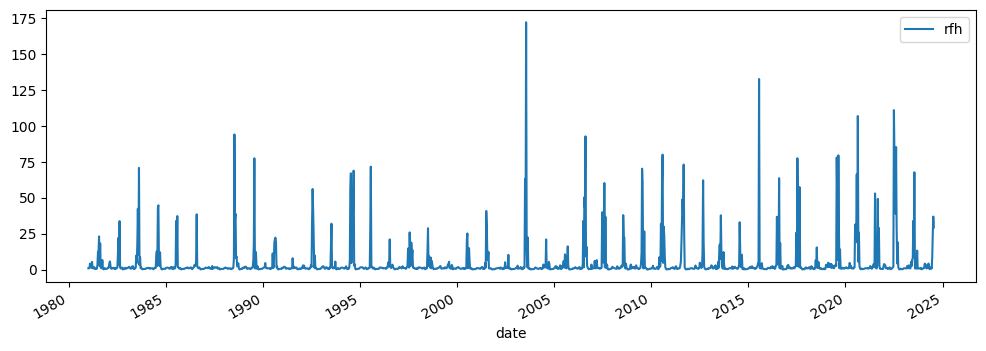

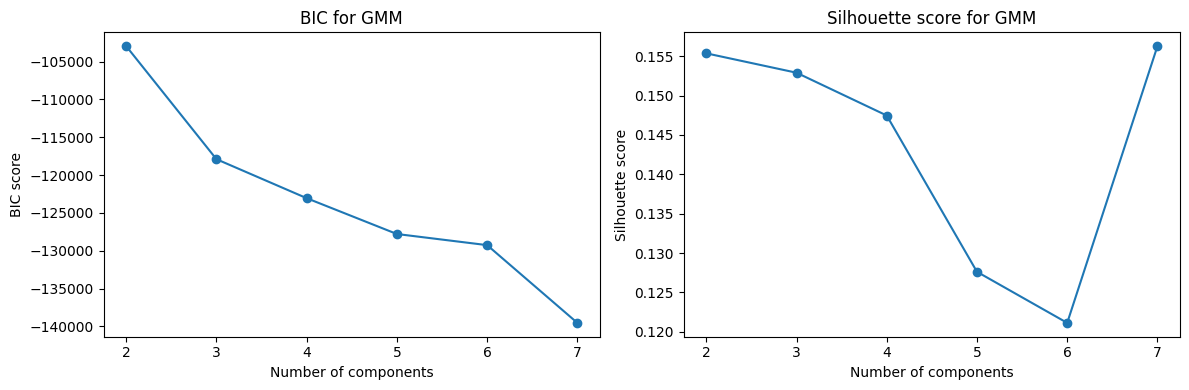

Optimal number of clusters (BIC): 7
rainfall_type_name
Type 0    1780
Type 2     725
Type 5     606
Type 3     545
Type 4     387
Type 6     349
Type 1     171
Name: count, dtype: int64
                    event_volume  mean_intensity  max_intensity  duration  \
rainfall_type_name                                                          
Type 0                     10.31           10.31          10.31      1.00   
Type 1                    221.03           45.18          90.82      5.39   
Type 2                     24.00           12.00          15.25      2.00   
Type 3                     39.54           10.43          16.18      3.79   
Type 4                     83.01           19.87          36.56      4.13   
Type 5                    188.64           19.02          43.34      9.74   
Type 6                    596.62           31.98          98.54     19.49   

                     rcvr  
rainfall_type_name         
Type 0               1.00  
Type 1               5.39  
Type 2  

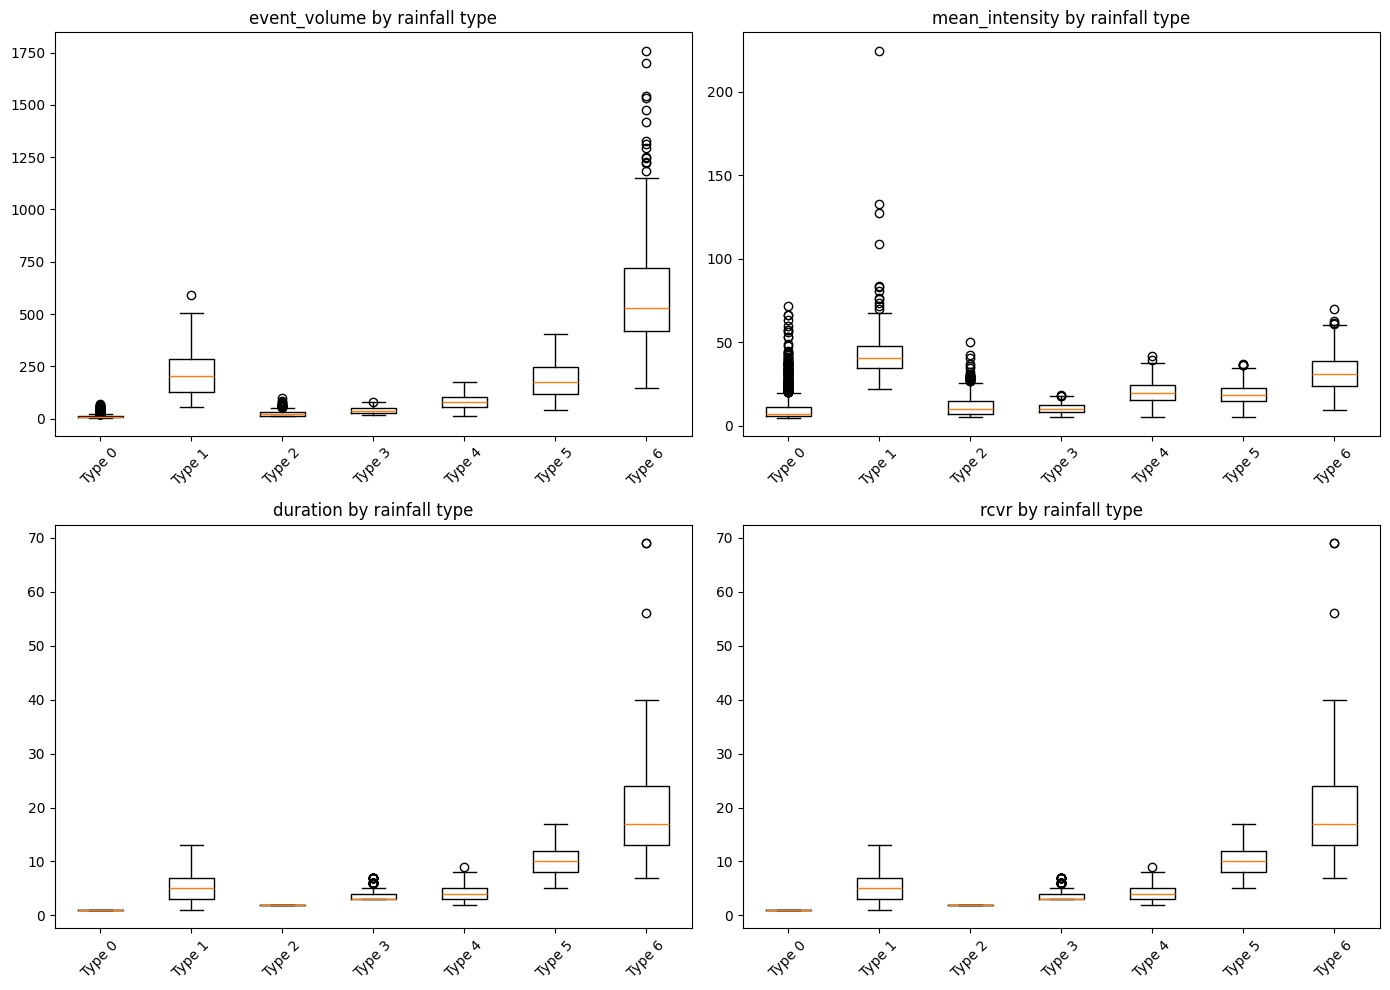

Saved clustered_rainfall_events.csv with event_year column
NaNs after cleaning: 0
LOGISTIC REGRESSION

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       356
           1       0.75      0.62      0.68        34
           2       0.63      0.52      0.57       145
           3       0.55      0.75      0.64       109
           4       0.71      0.38      0.50        78
           5       0.76      0.84      0.80       121
           6       0.90      0.91      0.91        70

    accuracy                           0.80       913
   macro avg       0.75      0.72      0.72       913
weighted avg       0.80      0.80      0.79       913

Weighted ROC-AUC: 0.9715

RANDOM FOREST


C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(



Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       356
           1       0.92      0.71      0.80        34
           2       0.99      1.00      0.99       145
           3       0.95      0.96      0.96       109
           4       0.85      0.92      0.88        78
           5       0.96      0.94      0.95       121
           6       0.94      0.94      0.94        70

    accuracy                           0.97       913
   macro avg       0.94      0.93      0.93       913
weighted avg       0.97      0.97      0.97       913


Top 5 Most Important Features:
          feature  importance
7            rcvr    0.244926
3        duration    0.223166
0    event_volume    0.169862
5   rise_gradient    0.103296
6  decay_gradient    0.101956
Weighted ROC-AUC: 0.9994

XGBOOST

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       356


C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       356
           1       0.92      0.68      0.78        34
           2       0.99      0.99      0.99       145
           3       0.92      0.95      0.94       109
           4       0.86      0.94      0.90        78
           5       0.94      0.88      0.91       121
           6       0.88      0.94      0.91        70

    accuracy                           0.96       913
   macro avg       0.93      0.91      0.92       913
weighted avg       0.96      0.96      0.96       913


Test Accuracy: 0.9562
Test Loss: 0.1000
Weighted ROC-AUC: 0.9989

MODEL COMPARISON


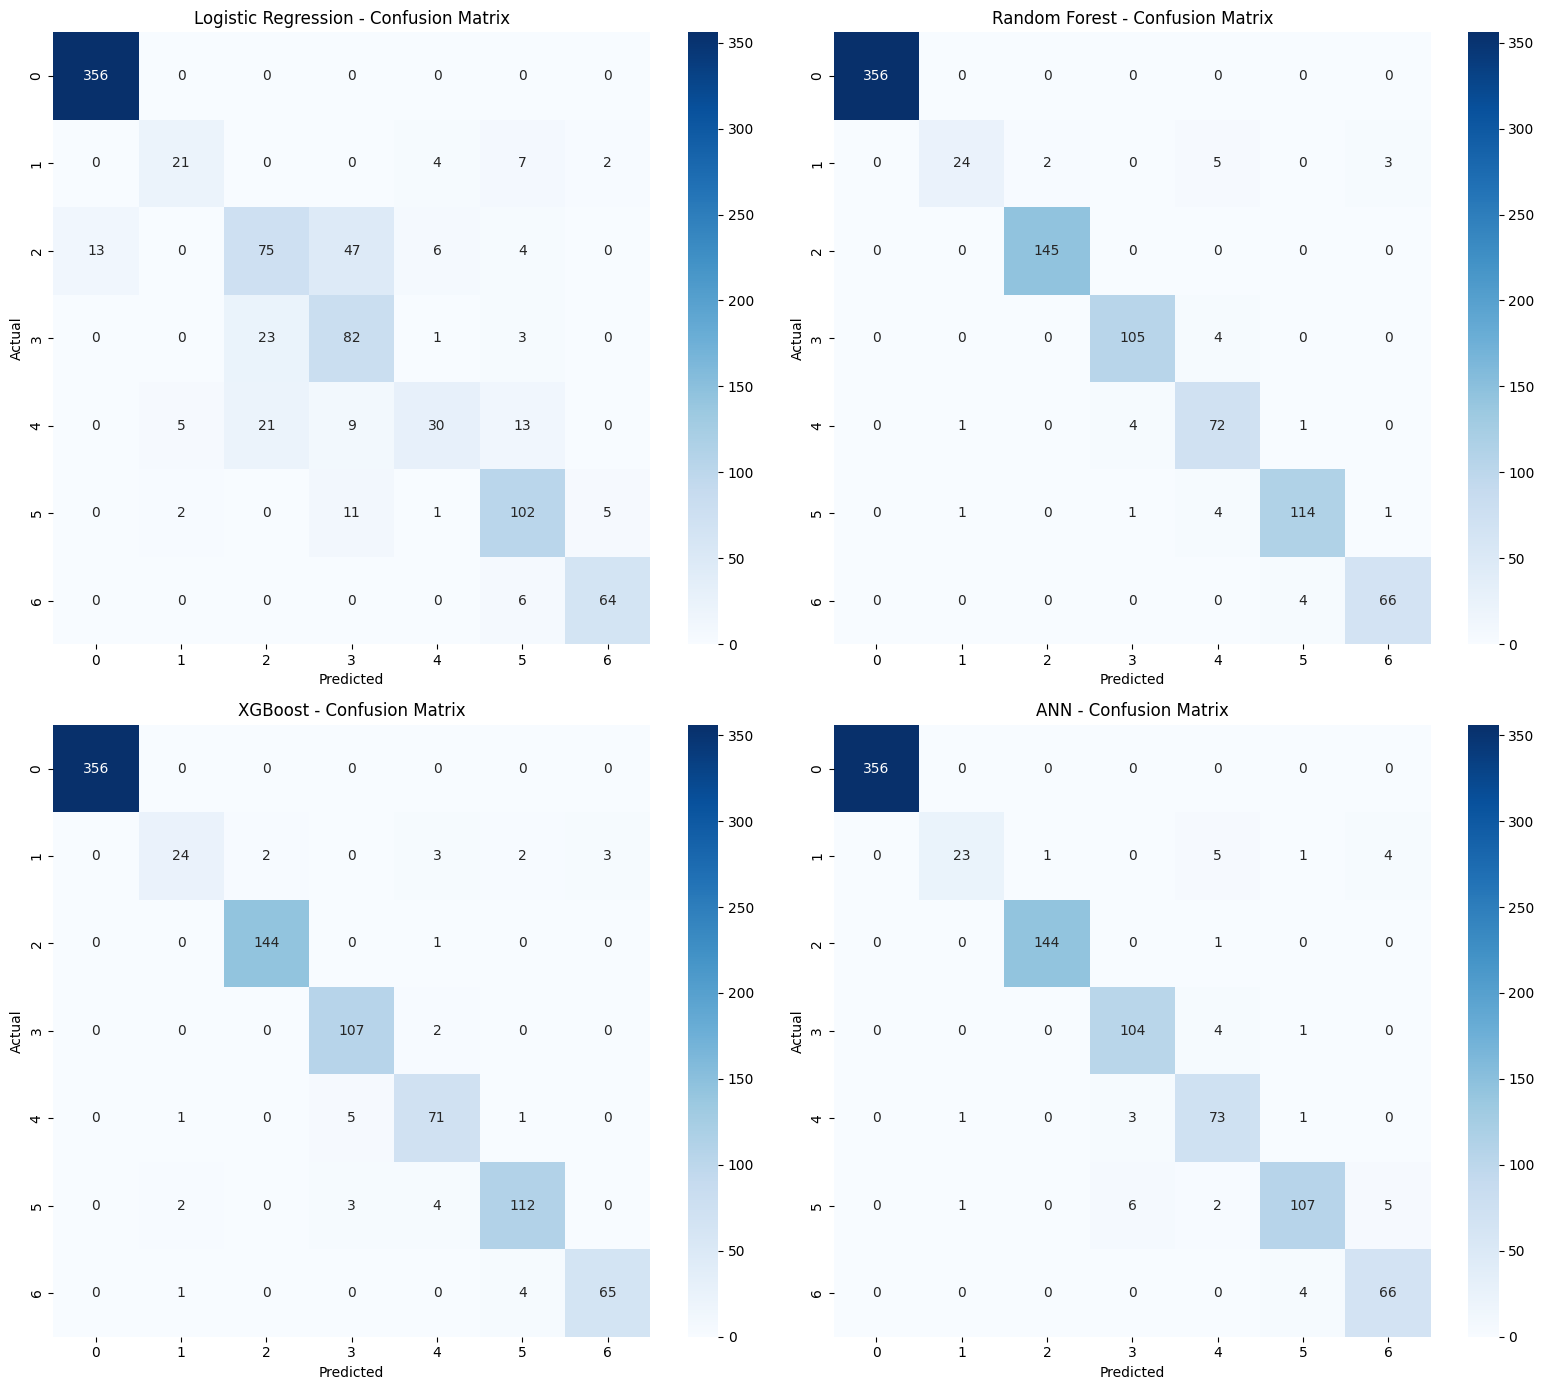

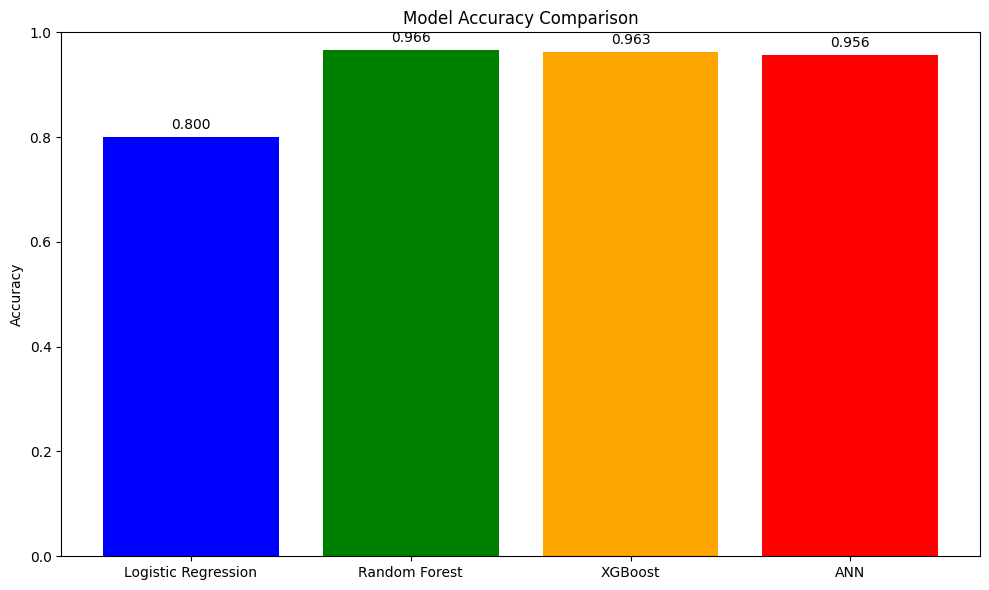

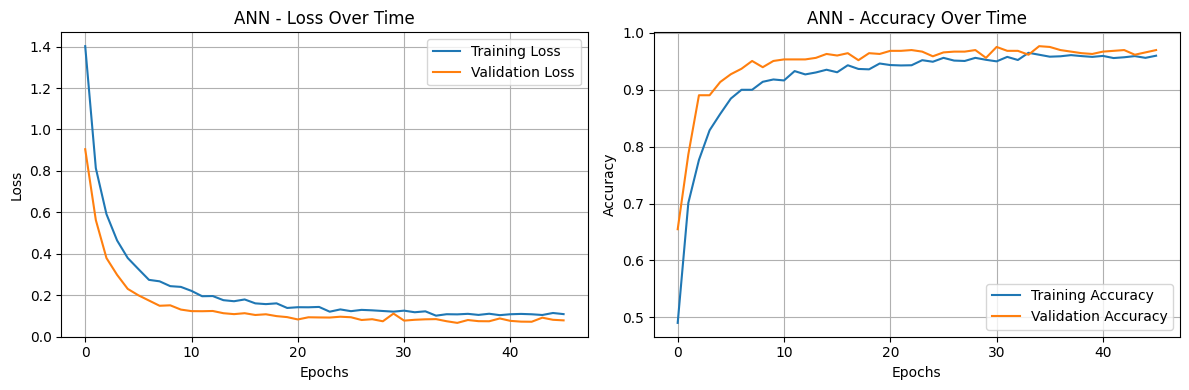

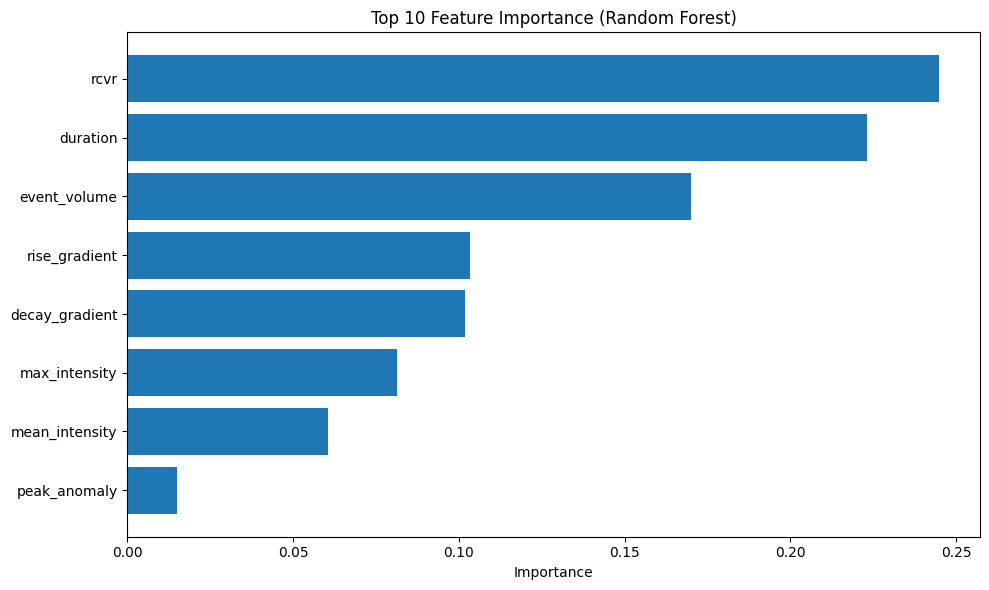


MODEL PERFORMANCE SUMMARY
              Model Accuracy
Logistic Regression   0.7996
      Random Forest   0.9660
            XGBoost   0.9628
                ANN   0.9562


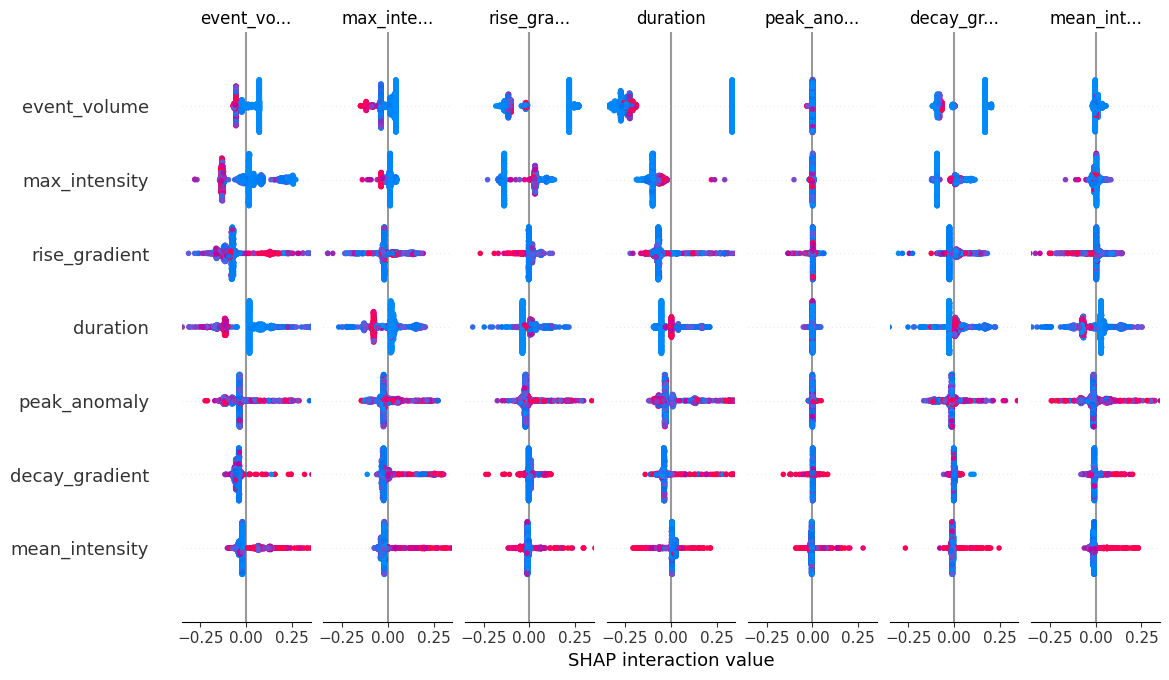

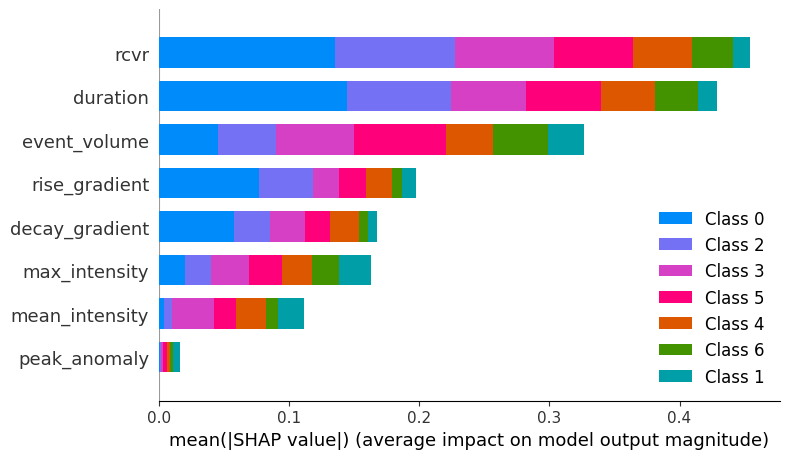

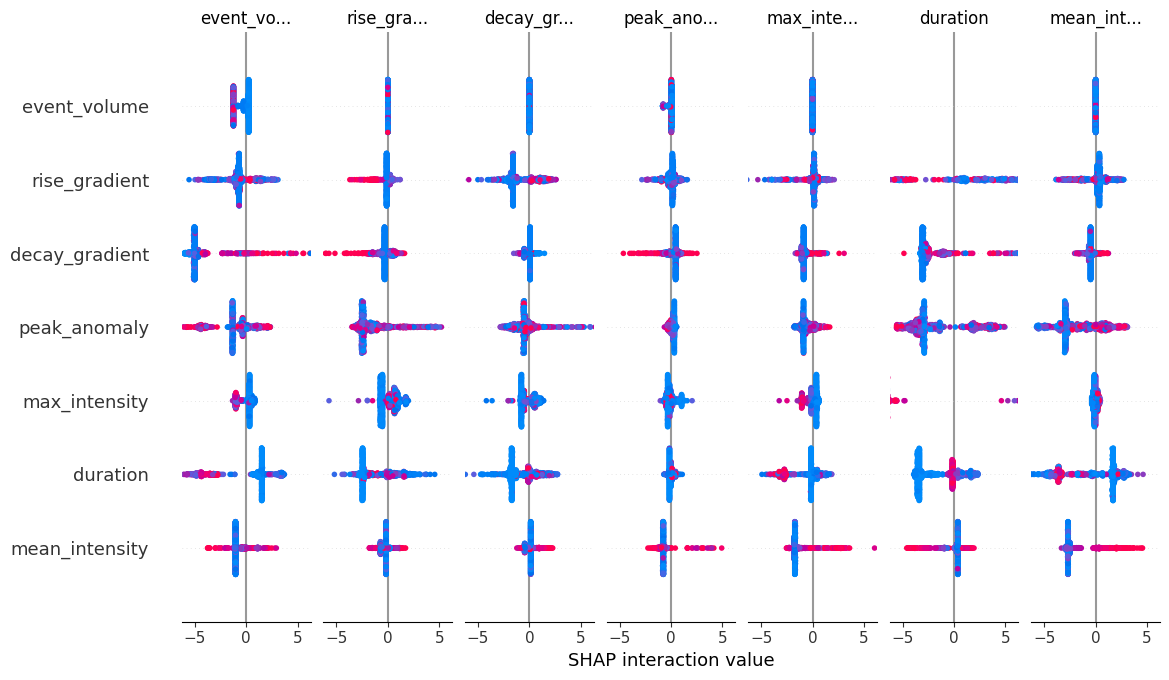

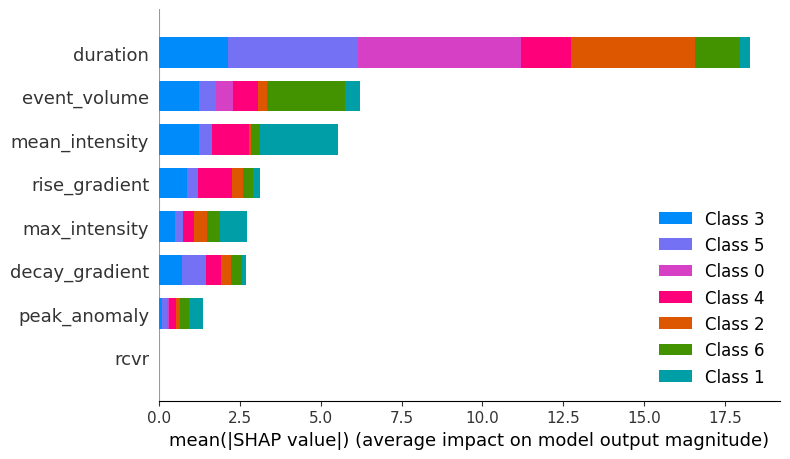


RAINFALL MORPHOLOGY & PHONOLOGY ANALYSIS
Total districts analyzed: 30
Total records: 47070
Total rainfall events: 4563

Rainfall type distribution:
rainfall_type_name
Type 0    0.390094
Type 2    0.158887
Type 5    0.132807
Type 3    0.119439
Type 4    0.084813
Type 6    0.076485
Type 1    0.037475
Name: proportion, dtype: float64

Best performing model:
Model: Random Forest
Accuracy: 0.9660

Top 5 Feature Importances:
       feature  importance
          rcvr    0.244926
      duration    0.223166
  event_volume    0.169862
 rise_gradient    0.103296
decay_gradient    0.101956


In [1]:
import pandas as pd
import os
import numpy as np
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelBinarizer
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from xgboost import XGBClassifier
from xgboost import XGBRegressor
import shap

df = pd.read_csv('Data/pakistan_rain.csv', skiprows=[1])

df.head()

df.info()

df.describe()

df.shape

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["adm2_id", "date"])
df = df.reset_index(drop=True)

df.isnull().sum()

df['is_wet'] = (df['rfh'] > 5).astype(int)
df['is_wet'].value_counts()

for i in range(0, 30, 3):
    district_id = df['adm2_id'].unique()[i]
    sample = df[df['adm2_id'] == district_id]

    sample.plot(x='date', y='rfh', figsize=(12, 4))

print(df['adm2_id'].unique())


def event_segmentation(df):
    events = []
    current_event = []
    in_event = False

    for idx, row in df.iterrows():
        if row['is_wet'] == 1:
            current_event.append(row)
            in_event = True
        else:
            if in_event and len(current_event) > 0:
                events.append(pd.DataFrame(current_event))
                current_event = []
            in_event = False

    if len(current_event) > 0:
        events.append(pd.DataFrame(current_event))

    return events


sample_district = df[df['adm2_id'] == df['adm2_id'].unique()[1]]
district_events = event_segmentation(sample_district)
print(f"Number of events:{len(district_events)}")


def extract_morphological_features(df):
    features = {}

    features['event_volume'] = df['rfh'].sum()
    features['mean_intensity'] = df['rfh'].mean()
    features['max_intensity'] = df['rfh'].max()
    features['duration'] = len(df)
    features['peak_anomaly'] = df['rfq'].max()

    if len(df) > 1:
        features['rise_gradient'] = (df['r1h'].iloc[-1] - df['r1h'].iloc[0]) / len(df)
        features['decay_gradient'] = (df['r3h'].iloc[-1] - df['r3h'].iloc[0]) / len(df)
    else:
        features['rise_gradient'] = 0
        features['decay_gradient'] = 0

    return features


for i, event in enumerate(district_events[0:3]):
    features = extract_morphological_features(event)
    print(f"Event{i}:{features}")


def calculate_phonological_features(events_series, window=30):
    features = {}

    if len(events_series) > 1:
        event_starts = [event['date'].iloc[0] for event in events_series]
        gaps = [(event_starts[i+1] - event_starts[i]).days for i in range(len(event_starts)-1)]

        features['mean_gap'] = np.mean(gaps)
        features['std_gap'] = np.std(gaps)
        features['gap_entropy'] = stats.entropy(np.histogram(gaps, bins=10)[0] + 1)
    else:
        features['mean_gap'] = 0
        features['std_gap'] = 0
        features['gap_entropy'] = 0

    if events_series:
        total_wet_days = sum(len(event) for event in events_series)
        features['rcvr'] = total_wet_days / max(1, len(events_series))
    else:
        features['rcvr'] = 0

    return features


phon_features = calculate_phonological_features(district_events)
print(phon_features)


def create_feature_matrix(df, district_events_map):
    feature_list = []

    for district_id, events in district_events_map.items():
        for event_idx, event in enumerate(events):
            morph = extract_morphological_features(event)
            phon = calculate_phonological_features([event])

            # Extract the year from the first date of the event
            event_year = event['date'].iloc[0].year

            feature_dict = {
                'district_id': district_id,
                'event_index': event_idx,
                'event_year': event_year,  # ADD THIS LINE
                'event_volume': morph['event_volume'],
                'mean_intensity': morph['mean_intensity'],
                'max_intensity': morph['max_intensity'],
                'duration': morph['duration'],
                'peak_anomaly': morph['peak_anomaly'],
                'rise_gradient': morph['rise_gradient'],
                'decay_gradient': morph['decay_gradient'],
                'rcvr': phon['rcvr']
            }
            feature_list.append(feature_dict)

    feature_df = pd.DataFrame(feature_list)

    features_to_scale = ['event_volume', 'mean_intensity', 'max_intensity',
                         'duration', 'peak_anomaly', 'rise_gradient',
                         'decay_gradient', 'rcvr']

    scaler = StandardScaler()
    feature_df_scaled = feature_df.copy()
    feature_df_scaled[features_to_scale] = scaler.fit_transform(feature_df[features_to_scale])

    return feature_df, feature_df_scaled, scaler


district_ids = df['adm2_id'].unique()
district_events_map = {}

for district_id in district_ids:
    district_data = df[df['adm2_id'] == district_id]
    district_events_map[district_id] = event_segmentation(district_data)

feature_df, feature_df_scaled, scaler = create_feature_matrix(df, district_events_map)
feature_df.head()

feature_df.shape

# Check if event_year was added successfully
print("Columns in feature_df:", feature_df.columns.tolist())
print("\nSample of event_year:")
print(feature_df[['district_id', 'event_index', 'event_year']].head(10))

X_raw = feature_df.drop(['district_id', 'event_index', 'event_year'], axis=1)

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_raw)

scaler = StandardScaler()
X = scaler.fit_transform(X_imputed)

bic_scores = []
silhouette_scores = []
n_components_range = range(2, 8)

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    labels = gmm.fit_predict(X)

    bic_scores.append(gmm.bic(X))

    if len(np.unique(labels)) > 1:
        silhouette_scores.append(silhouette_score(X, labels))
    else:
        silhouette_scores.append(-1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(n_components_range, bic_scores, marker='o')
ax1.set_xlabel('Number of components')
ax1.set_ylabel('BIC score')
ax1.set_title('BIC for GMM')

ax2.plot(n_components_range, silhouette_scores, marker='o')
ax2.set_xlabel('Number of components')
ax2.set_ylabel('Silhouette score')
ax2.set_title('Silhouette score for GMM')

plt.tight_layout()
plt.show()

optimal_n = n_components_range[np.argmin(bic_scores)]
print(f"Optimal number of clusters (BIC): {optimal_n}")

final_gmm = GaussianMixture(n_components=optimal_n, random_state=42)
labels = final_gmm.fit_predict(X)

feature_df['rainfall_type'] = labels

typology_names = {
    i: f"Type {i}" for i in range(optimal_n)
}

feature_df['rainfall_type_name'] = feature_df['rainfall_type'].map(typology_names)

print(feature_df['rainfall_type_name'].value_counts())

import matplotlib.pyplot as plt

cluster_stats = feature_df.groupby('rainfall_type_name').agg({
    'event_volume': 'mean',
    'mean_intensity': 'mean',
    'max_intensity': 'mean',
    'duration': 'mean',
    'rcvr': 'mean'
}).round(2)

print(cluster_stats)

features_to_plot = ['event_volume', 'mean_intensity', 'duration', 'rcvr']
rainfall_types = sorted(feature_df['rainfall_type_name'].unique())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feature in zip(axes.ravel(), features_to_plot):

    data = [
        feature_df[feature_df['rainfall_type_name'] == typ][feature]
        for typ in rainfall_types
    ]

    ax.boxplot(data, tick_labels=rainfall_types)
    ax.set_title(f'{feature} by rainfall type')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Save the dataframe with event_year included
feature_df.to_csv('clustered_rainfall_events.csv', index=False)
print("Saved clustered_rainfall_events.csv with event_year column")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


def prepare_prediction_data(df, feature_df_with_types):

    prediction_features = []

    for district in df['adm2_id'].unique():
        district_data = df[df['adm2_id'] == district].copy()

        district_data['month'] = pd.DatetimeIndex(district_data['date']).month
        district_data['dekad_in_month'] = pd.DatetimeIndex(district_data['date']).day.apply(
            lambda x: 0 if x <= 10 else (1 if x <= 20 else 2)
        )
        district_data['rolling_mean_3'] = district_data['rfh'].rolling(3, min_periods=1).mean()
        district_data['rolling_std_3'] = district_data['rfh'].rolling(3, min_periods=1).std()

        prediction_features.append(district_data)

    return pd.concat(prediction_features, ignore_index=True)


# Prepare the data for modeling - now we need to drop event_year from features
X = feature_df.drop(['district_id', 'event_index', 'event_year', 'rainfall_type', 'rainfall_type_name'], axis=1)
y = feature_df['rainfall_type']

imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

scaler = StandardScaler()
X = scaler.fit_transform(X)

print("NaNs after cleaning:", np.isnan(X).sum())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Dictionary to store all model results
models_results = {}

# 1. Logistic Regression
print("="*50)
print("LOGISTIC REGRESSION")
print("="*50)
lr = LogisticRegression(max_iter=1000, multi_class='ovr', random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_pred_proba = lr.predict_proba(X_test)

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

# Calculate ROC AUC (for multi-class)
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)
try:
    lr_roc_auc = roc_auc_score(y_test_bin, lr_pred_proba, multi_class='ovr', average='weighted')
    print(f"Weighted ROC-AUC: {lr_roc_auc:.4f}")
except:
    print("ROC-AUC calculation skipped (may be due to class imbalance)")

models_results['Logistic Regression'] = {
    'model': lr,
    'predictions': lr_pred,
    'probabilities': lr_pred_proba,
    'y_test': y_test
}

# 2. Random Forest
print("\n" + "="*50)
print("RANDOM FOREST")
print("="*50)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_pred_proba = rf.predict_proba(X_test)

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

# Feature importance
feature_names = feature_df.drop(['district_id', 'event_index', 'event_year', 'rainfall_type', 'rainfall_type_name'], axis=1).columns
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 5 Most Important Features:")
print(feature_importance.head())

try:
    rf_roc_auc = roc_auc_score(y_test_bin, rf_pred_proba, multi_class='ovr', average='weighted')
    print(f"Weighted ROC-AUC: {rf_roc_auc:.4f}")
except:
    print("ROC-AUC calculation skipped")

models_results['Random Forest'] = {
    'model': rf,
    'predictions': rf_pred,
    'probabilities': rf_pred_proba,
    'y_test': y_test
}

# 3. XGBoost
print("\n" + "="*50)
print("XGBOOST")
print("="*50)
xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_pred_proba = xgb.predict_proba(X_test)

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

try:
    xgb_roc_auc = roc_auc_score(y_test_bin, xgb_pred_proba, multi_class='ovr', average='weighted')
    print(f"Weighted ROC-AUC: {xgb_roc_auc:.4f}")
except:
    print("ROC-AUC calculation skipped")

models_results['XGBoost'] = {
    'model': xgb,
    'predictions': xgb_pred,
    'probabilities': xgb_pred_proba,
    'y_test': y_test
}

# 4. Artificial Neural Network
print("\n" + "="*50)
print("ARTIFICIAL NEURAL NETWORK")
print("="*50)

num_classes = len(np.unique(y_train))
input_dim = X_train.shape[1]
num_classes = len(set(y_train))

# Build the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(input_dim,)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=0
)

# Evaluate on test set
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Calculate test accuracy
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

try:
    ann_roc_auc = roc_auc_score(y_test_bin, y_pred_proba, multi_class='ovr', average='weighted')
    print(f"Weighted ROC-AUC: {ann_roc_auc:.4f}")
except:
    print("ROC-AUC calculation skipped")

models_results['ANN'] = {
    'model': model,
    'predictions': y_pred,
    'probabilities': y_pred_proba,
    'history': history,
    'y_test': y_test
}

# COMPARATIVE VISUALIZATIONS
print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)

# 1. Plot confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.ravel()

for idx, (model_name, results) in enumerate(models_results.items()):
    cm = confusion_matrix(results['y_test'], results['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_title(f'{model_name} - Confusion Matrix')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# 2. Compare model accuracies
model_names = list(models_results.keys())
accuracies = []

for model_name, results in models_results.items():
    if model_name == 'ANN':
        _, accuracy = model.evaluate(X_test, y_test, verbose=0)
    else:
        accuracy = (results['predictions'] == results['y_test']).mean()
    accuracies.append(accuracy)

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, accuracies, color=['blue', 'green', 'orange', 'red'])
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylim([0, 1])

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# 3. Plot ANN training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('ANN - Loss Over Time')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('ANN - Accuracy Over Time')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 4. Feature Importance from Random Forest (most interpretable model)
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importance')
plt.title('Top 10 Feature Importance (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 5. Summary table
print("\n" + "="*50)
print("MODEL PERFORMANCE SUMMARY")
print("="*50)
summary_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': [f'{acc:.4f}' for acc in accuracies]
})
print(summary_df.to_string(index=False))

# SHAP Analysis
original_feature_names = feature_df.drop(['district_id', 'event_index', 'event_year', 'rainfall_type', 'rainfall_type_name'], axis=1).columns.tolist()

X_test_df = pd.DataFrame(X_test, columns=original_feature_names)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_df)

shap.summary_plot(shap_values, X_test_df, feature_names=original_feature_names)
plt.show()

shap.summary_plot(shap_values, X_test_df, feature_names=original_feature_names, plot_type="bar")
plt.show()

xgb_explainer = shap.TreeExplainer(xgb)
xgb_shap_values = xgb_explainer.shap_values(X_test_df)

shap.summary_plot(xgb_shap_values, X_test_df, feature_names=original_feature_names)
plt.show()

shap.summary_plot(xgb_shap_values, X_test_df, feature_names=original_feature_names, plot_type="bar")
plt.show()

# Skip KernelExplainer for Logistic Regression as it's computationally expensive
# Skip GradientExplainer for ANN as it requires additional setup

print("\n" + "=" * 50)
print("RAINFALL MORPHOLOGY & PHONOLOGY ANALYSIS")
print("=" * 50)
print(f"Total districts analyzed: {len(df['adm2_id'].unique())}")
print(f"Total records: {len(df)}")
print(f"Total rainfall events: {len(feature_df)}")
print("\nRainfall type distribution:")
print(feature_df['rainfall_type_name'].value_counts(normalize=True))
print("\nBest performing model:")

model_names = list(models_results.keys())
accuracies = []

for model_name, results in models_results.items():
    if model_name == 'ANN':
        _, accuracy = model.evaluate(X_test, y_test, verbose=0)
    else:
        accuracy = (results['predictions'] == results['y_test']).mean()
    accuracies.append(accuracy)

best_model_idx = np.argmax(accuracies)
best_model_name = model_names[best_model_idx]
best_model_accuracy = accuracies[best_model_idx]

print(f"Model: {best_model_name}")
print(f"Accuracy: {best_model_accuracy:.4f}")

if best_model_name == 'Random Forest':
    print("\nTop 5 Feature Importances:")
    feature_names = feature_df.drop(['district_id', 'event_index', 'event_year', 'rainfall_type', 'rainfall_type_name'], axis=1).columns
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)
    print(feature_importance.head(5).to_string(index=False))